In [1]:
from learn_to_infer import Worker
from task import Mastermind
import pandas as pd
import torch
import numpy as np
from optimality import Optimality

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [2]:
self = Optimality(
    Mastermind(n_trials=200),
)

In [3]:
# learn task A
self.env._generate_task_schedule(nb_tasks=1000)
all_map_particles, selected_actions, outcome_of_selected_actions = self.infer(nb_particles=2000)

Inferring: 100%|██████████| 200/200 [1:10:46<00:00, 21.23s/it]


In [10]:
# Sort nus into bins with equal number of points
nb_bins = 10
nus = self.env.nu.mean(axis=1)
sorted_bins = np.percentile(nus, np.linspace(0, 100, nb_bins + 1))
digited_bins = np.digitize(nus, sorted_bins) - 1
nus_native = np.zeros([nb_bins])
nus_learned = np.zeros([nb_bins])
for bin in range(nb_bins):
    print(f"Bin {bin}: {nus[digited_bins == bin].mean()}, n={np.sum(digited_bins == bin)}")
    nus_native[bin] = self.env.nu[digited_bins == bin].mean()
    nus_learned[bin] = all_map_particles[-1, digited_bins == bin, 0].mean(axis=(0))

Bin 0: 0.00487894967314411, n=100
Bin 1: 0.014880712564027286, n=100
Bin 2: 0.026247708674848724, n=100
Bin 3: 0.03811029225634123, n=100
Bin 4: 0.05120955870540712, n=100
Bin 5: 0.0658263181037517, n=100
Bin 6: 0.08444918117552441, n=100
Bin 7: 0.10694785262458831, n=100
Bin 8: 0.13631316763914555, n=100
Bin 9: 0.1697738258233201, n=99


Text(0, 0.5, 'Inferred mean volatility')

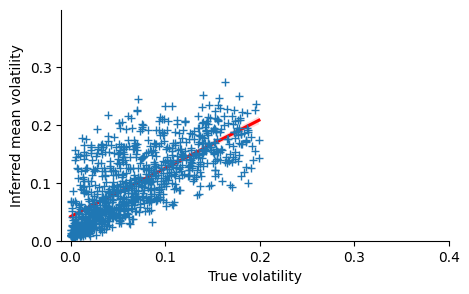

In [12]:
import seaborn as sns

nus = self.env.nu.mean(axis=1)
inferred_vol = [all_map_particles[-1, nus ==  nu, 0] for nu in np.unique(nus)]
mean_vol = np.array([np.mean(v) for v in inferred_vol])
std_vol = np.array([np.std(v) for v in inferred_vol])

plt.figure(figsize=(5, 3))
plt.errorbar(np.unique(nus), mean_vol, yerr=std_vol, capsize=0, capthick=0, linestyle='None', marker='+')

# Add linear regression with confidence interval
unique_nus = np.unique(nus)
sns.regplot(x=unique_nus, y=mean_vol, scatter=False, color='red')

plt.ylim([0, 0.4])
plt.gca().set_yticks([0,  0.1, 0.2, 0.3])
plt.gca().set_xticks([0,  0.1, 0.2, 0.3, 0.4])
plt.gca().spines[['right', 'top']].set_visible(False)
plt.xlabel('True volatility')
plt.ylabel('Inferred mean volatility')

In [2]:
import numpy as np

# Define the parameter ranges
range_of_vols = [0.001, 0.01, 0.02, 0.05, 0.10]
range_of_ffs = [0.05, 0.1, 0.15, 0.2]

nb_tasks = 2000
vols_grid, ffs_grid= np.meshgrid(range_of_vols, range_of_ffs, indexing='ij')
vols, ffs= vols_grid.ravel(), ffs_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]

nb_bins_volatility = len(range_of_vols)
nb_bins_falsefeedback = len(range_of_ffs)

from scipy.stats import spearmanr, pearsonr
import warnings
warnings.simplefilter("error", RuntimeWarning)
from tqdm import tqdm
nb_simul = 1
nb_trials = 1000


In [4]:
# nb particles, time and performance
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.simplefilter("error", RuntimeWarning)
import time
from tqdm import tqdm
import numpy as np

nb_simul = 1
nb_trials = 1000
list_nb_particles = [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
timings_nb_particles = np.zeros([len(list_nb_particles), nb_tasks])
performances_nb_particles = np.zeros([len(list_nb_particles), nb_tasks])

for i, nb_particles in enumerate(list_nb_particles):
    self = Optimality(
        Mastermind(n_trials=nb_trials),
    )

    np.random.seed(0)
    torch.manual_seed(0)
    self.env._generate_task_schedule(nb_tasks=nb_tasks, nus=vols, ffbs=ffs)
    import time
    start_time = time.time()
    all_particles_map, selected_actions, outcome_of_selected_actions = self.infer(nb_particles=nb_particles)
    end_time = time.time()
    timings_nb_particles[i, :] = end_time - start_time
    performances_nb_particles[i, :] = (selected_actions == self.env.correct_arms).mean(axis=1)

Inferring: 100%|██████████| 1000/1000 [07:01<00:00,  2.37it/s]


AttributeError: 'Mastermind' object has no attribute 'correct_arms'

In [6]:
(selected_actions == self.env.correct_action).mean()

0.807975

In [ ]:
self = Optimality(
    Mastermind(n_trials=nb_trials),
)
 
np.random.seed(0)
torch.manual_seed(0)
self.env._generate_task_schedule(nb_tasks=nb_tasks, nus=vols, ffbs=ffs)
result = self.infer(nb_particles=2000)

Inferring: 100%|██████████| 1000/1000 [18:40:39<00:00, 67.24s/it] 


In [31]:
import pickle
#pickle.dump([result, self], open("result_optimality.pkl", "wb"))

[result, self] = pickle.load(open("result_optimality.pkl", "rb"))

In [32]:
all_particles_map, selected_actions, outcome_of_selected_actions = result
transitions, ffr = all_particles_map.T
transitions.shape

(2000, 1000)

In [33]:
result={
    'params_transition': transitions, 
    'actions': selected_actions, 
    'outcome_of_selected_actions': outcome_of_selected_actions,
    'false_positive_rate': ffr
}
index = 1

In [34]:
# performance
performance = np.zeros([nb_simul])
performance_stds = np.zeros([nb_simul])

# volatility
nus_native = np.zeros([nb_simul, nb_bins_volatility])
nus_learned = np.zeros([nb_simul, nb_bins_volatility])
nus_learned_stds = np.zeros([nb_simul, nb_bins_volatility])
out_rewards_nus = np.zeros([nb_simul, nb_bins_volatility])
out_rewards_nus_stds = np.zeros([nb_simul, nb_bins_volatility])
nus_falsefeedback_learned = np.zeros([nb_simul, nb_bins_volatility])
nus_falsefeedback_learned_stds = np.zeros([nb_simul, nb_bins_volatility])
nus_function_of_trials = np.zeros([nb_simul, nb_tasks, nb_trials])

# false feedback
false_positive_rate_native = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_learned = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_learned_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
out_rewards_falsefeedback = np.zeros([nb_simul, nb_bins_falsefeedback])
out_rewards_falsefeedback_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_nus_learned = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_nus_learned_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_function_of_trials = np.zeros([nb_simul, nb_tasks, nb_trials])

In [35]:
# volatility
nus = self.env.nu.mean(axis=1)
sorted_bins = np.array([0] + range_of_vols) + 1e-9
digited_bins = np.digitize(nus, sorted_bins, right=True) - 1
digited_bins[digited_bins == nb_bins_volatility] = nb_bins_volatility - 1 # bin nb_bins_volatility-1 is skipped

# false feedback
false_positive_rate = self.env.ffb.mean(axis=1)
sorted_bins_falsefeedback = np.array([0] + range_of_ffs) + 1e-9
digited_bins_falsefeedback = np.digitize(false_positive_rate, sorted_bins_falsefeedback, right=True) - 1
assert((digited_bins_falsefeedback != nb_bins_falsefeedback).all())
digited_bins_falsefeedback[digited_bins_falsefeedback == nb_bins_falsefeedback] = nb_bins_falsefeedback - 1 # bin nb_bins_falsefeedback-1 is skipped

In [36]:
# rewards x volatility
chosen_correct_action = (result['actions'] == self.env.correct_action)
performance = chosen_correct_action.mean()
obtained_rewards = [chosen_correct_action[digited_bins == nu] for nu in range(nb_bins_volatility)]
out_rewards_nus[index - 1, :] = np.array([np.mean(v) for v in obtained_rewards])
out_rewards_nus_stds[index - 1, :] = np.array([np.std(v) for v in obtained_rewards])

obtained_rewards_falsefeedback = [chosen_correct_action[digited_bins_falsefeedback == nu] for nu in range(nb_bins_falsefeedback)]
out_rewards_falsefeedback[index - 1, :] = np.array([np.mean(v) for v in obtained_rewards_falsefeedback])
out_rewards_falsefeedback_stds[index - 1, :] = np.array([np.std(v) for v in obtained_rewards_falsefeedback])

In [38]:
for bin in range(nb_bins_volatility):
    nus_native[index - 1, bin] = self.env.nu[digited_bins == bin].mean()
    nus_learned[index - 1, bin] = result["params_transition"][digited_bins == bin, -1].mean(axis=0)
    nus_learned_stds[index - 1, bin] = result["params_transition"][digited_bins == bin, -1].std(axis=0)
    nus_falsefeedback_learned[index - 1, bin] = result['false_positive_rate'][digited_bins == bin, -1].mean(axis=0)
    nus_falsefeedback_learned_stds[index - 1, bin] = result['false_positive_rate'][digited_bins == bin, -1].std(axis=0)
nus_function_of_trials[index - 1, :] = result["params_transition"]

# false feedback
for bin in range(nb_bins_falsefeedback):
    false_positive_rate_native[index - 1, bin] = self.env.ffb[digited_bins_falsefeedback == bin, -1].mean(axis=0)
    false_positive_rate_learned[index - 1, bin] = result['false_positive_rate'][digited_bins_falsefeedback == bin, -1].mean(axis=0)
    false_positive_rate_learned_stds[index - 1, bin] = result['false_positive_rate'][digited_bins_falsefeedback == bin, -1].std(axis=0)
    false_positive_rate_nus_learned[index - 1, bin] = result['params_transition'][digited_bins_falsefeedback == bin, -1].mean(axis=0)
    false_positive_rate_nus_learned_stds[index - 1, bin] = result['params_transition'][digited_bins_falsefeedback == bin, -1].std(axis=0)

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_61190/407233561.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', estimations_means_vol.shape[1] + 2)  # +2 to avoid pure white


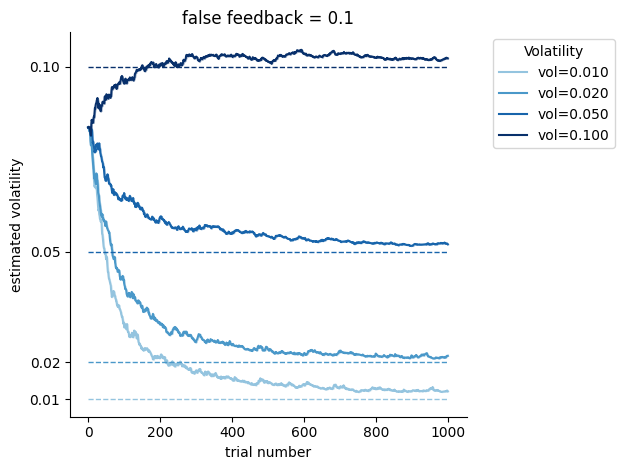

In [49]:
unique_vols = np.unique(vols)[1:]
estimations_means_vol = np.hstack([nus_function_of_trials[:, (vols==v) * (ffs==0.1)].mean(axis=1, keepdims=True) for v in unique_vols])

nb_trials = 1000
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create a colormap with as many shades as unique_vols
cmap = cm.get_cmap('Blues', estimations_means_vol.shape[1] + 2)  # +2 to avoid pure white

fig, ax = plt.subplots()
for i in range(estimations_means_vol.shape[1]):
    color = cmap(i + 2)  # skip the lightest colors
    ax.plot(estimations_means_vol[:, i, 1:nb_trials].mean(axis=0), color=color, label=f'vol={unique_vols[i]:.3f}')
    ax.fill_between(np.arange(1, nb_trials), 
        estimations_means_vol[:, i, 1:nb_trials].mean(axis=0) - estimations_means_vol[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means_vol.shape[0]), 
        estimations_means_vol[:, i, 1:nb_trials].mean(axis=0) + estimations_means_vol[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means_vol.shape[0]), 
        color=color, alpha=0.3)
    ax.plot([0, nb_trials], [unique_vols[i], unique_vols[i]], color=color, linestyle='--', linewidth=1)
ax.set_xlabel('True volatility')
ax.legend(title="Volatility", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('trial number')
ax.set_ylabel('estimated volatility')
ax.set_title('false feedback = 0.1')
ax.set_yticks(unique_vols)
# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('figures/volatility_trial_number_dec2025.pdf')

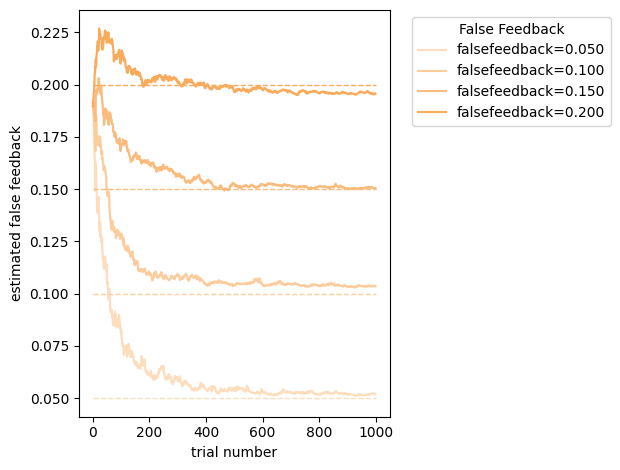

In [50]:
unique_falsefeedback = np.unique(ffs)
estimations_means_ff = np.hstack([result['false_positive_rate'][None][:, (ffs==v) * (vols==0.05)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

nb_trials = 1000
# Create a colormap gradient of "#F8993A"
base_color = "#F8993A"
# We'll make a light-to-dark gradient using the base color and white
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, estimations_means_ff.shape[1] + 2):
    # Interpolate between white and base_color
    interp = i / (estimations_means_ff.shape[1] + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
# Use the list of colors as gradient

for i in range(estimations_means_ff.shape[1]):
    color = colors[i + 2]  # skip the lightest colors (to avoid pure white)
    plt.plot(estimations_means_ff[:, i, :nb_trials].mean(axis=0), color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.fill_between(np.arange(1, nb_trials), 
        estimations_means_ff[:, i, 1:nb_trials].mean(axis=0) - estimations_means_ff[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means_ff.shape[0]), 
        estimations_means_ff[:, i, 1:nb_trials].mean(axis=0) + estimations_means_ff[:, i, 1:nb_trials].std(axis=0) / np.sqrt(estimations_means_ff.shape[0]), 
        color=color, alpha=0.3)
    plt.plot([0, nb_trials], [unique_falsefeedback[i], unique_falsefeedback[i]], color=color, linestyle='--', linewidth=1)
plt.xlabel('False Feedback Rate')
plt.legend(title="False Feedback", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('trial number')
plt.ylabel('estimated false feedback')
plt.tight_layout()
#plt.savefig('figures/falsefeedback_trial_number_dec2025.pdf')

In [52]:
# save output results

pickle.dump([chosen_correct_action.mean(axis=-1), unique_vols, unique_falsefeedback, estimations_means_ff.squeeze(), estimations_means_vol.squeeze()], open("result_optimality_processed.pkl", "wb"))

### Add reversal curves

In [3]:
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.simplefilter("error", RuntimeWarning)
from tqdm import tqdm
nb_trials = 1000
nb_tasks = 2000

np.random.seed(0)
first_combination = np.random.randint(0, 24, [nb_tasks])
end_combination = np.array([np.random.choice(np.delete(np.arange(24), c)) for c in first_combination])
correct_combinations = np.zeros([nb_tasks, nb_trials], dtype=int)
correct_combinations[:, :500] = first_combination[:, None]
correct_combinations[:, 500:] = end_combination[:, None]

self = Optimality(
    Mastermind(n_trials=nb_trials),
)

np.random.seed(0)
torch.manual_seed(0)
self.env._generate_task_schedule(nb_tasks=nb_tasks, correct_combinations=correct_combinations, ffbs=[0.2] * len(correct_combinations))
result_rev = self.infer(nb_particles=2000)

Inferring: 100%|██████████| 1000/1000 [19:59:31<00:00, 71.97s/it]    


In [ ]:
import pickle
##pickle.dump([result_rev, self], open("result_optimality_rev.pkl", "wb"))
[result_rev, self] = pickle.load(open("result_optimality_rev.pkl", "rb"))

In [14]:
all_particles_map, selected_actions, outcome_of_selected_actions = result_rev
performance = (selected_actions == self.env.correct_action)

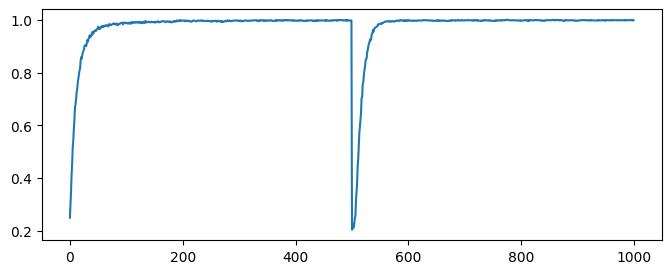

In [15]:
plt.figure(figsize=(8, 3))
plt.plot(performance.T.mean(axis=1))